<a href="https://colab.research.google.com/github/ArtiManral/Netflix_Movie_Data_Analysis/blob/main/Airbnb_Hotel_Booking_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [6]:
# Read the AirBnb Data
df = pd.read_excel('/content/1730285881-Airbnb_Open_Data.xlsx')


In [7]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102599 non-null  int64         
 1   NAME                            102329 non-null  object        
 2   host id                         102599 non-null  int64         
 3   host_identity_verified          102310 non-null  object        
 4   host name                       102191 non-null  object        
 5   neighbourhood group             102570 non-null  object        
 6   neighbourhood                   102583 non-null  object        
 7   lat                             102591 non-null  float64       
 8   long                            102591 non-null  float64       
 9   country                         102067 non-null  object        
 10  country code                    102468 non-null  object 

In [9]:
df.duplicated().value_counts()

,count
False,102058
True,541


In [12]:
#Drop duplicate records
df.drop_duplicates(inplace=True)

#Remove all dollar signs in the price and service fee columns
df['price'] = df['price'].astype(str).str.replace('$', '', regex=False)
df['service fee'] = df['service fee'].astype(str).str.replace('$', '', regex=False)

#Rename the price and service fee columns to include a dollar sign
df.rename(columns=
 {'price':'price_$','service fee':'service_fee_$'
 },inplace=True)

#Drop all records with missing values
df.dropna(inplace = True)

#Change all mismatched data types to appropriate once.
df['price_$'] = df['price_$'].astype('float')
df['service_fee_$'] = df['service_fee_$'].astype('float')
df['id'] = df['id'].astype('str')
df['host id'] = df['host id'].astype('str')
df['last review']= pd.to_datetime(df['last review'])
df['Construction year'] = df['Construction year'].astype('int')

In [13]:
df.duplicated().value_counts()

,count
False,83797


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83797 entries, 0 to 102057
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              83797 non-null  object        
 1   NAME                            83797 non-null  object        
 2   host id                         83797 non-null  object        
 3   host_identity_verified          83797 non-null  object        
 4   host name                       83797 non-null  object        
 5   neighbourhood group             83797 non-null  object        
 6   neighbourhood                   83797 non-null  object        
 7   lat                             83797 non-null  float64       
 8   long                            83797 non-null  float64       
 9   country                         83797 non-null  object        
 10  country code                    83797 non-null  object        
 11  instan

#**Explorartory Data Analysis**


In [15]:
df.describe()

,lat,long,instant_bookable,Construction year,price_$,service_fee_$,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,83797.000000,83797.000000,83797.000000,83797.000000,83597.000000,83568.000000,83797.000000,83797.000000,83797,83797.000000,83797.000000,83797.000000,83797.000000
mean,40.727355,-73.948502,0.497727,2012.489481,626.349151,125.233774,7.436722,32.229006,2019-06-09 15:15:56.697733888,1.375618,3.278841,7.049835,141.801341
min,40.504560,-74.249840,0.000000,2003.000000,50.000000,10.000000,-365.000000,1.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,-10.000000
25%,40.687660,-73.982110,0.000000,2007.000000,340.000000,68.000000,2.000000,3.000000,2018-10-27 00:00:00,0.220000,2.000000,1.000000,6.000000
50%,40.721340,-73.953710,0.000000,2012.000000,625.000000,125.000000,3.000000,11.000000,2019-06-13 00:00:00,0.740000,3.000000,1.000000,101.000000
75%,40.762580,-73.930790,1.000000,2017.000000,914.000000,183.000000,5.000000,38.000000,2019-07-05 00:00:00,2.010000,4.000000,2.000000,266.000000
max,40.916970,-73.705220,1.000000,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2022-05-21 00:00:00,90.000000,5.000000,332.000000,3677.000000
std,0.056317,0.050338,0.499998,5.760501,331.813050,66.358543,28.122748,51.902177,NaN,1.749447,1.283730,29.568531,133.965307


In [16]:
#What are the different property types in the dataset?

property_types = df['room type'].value_counts().to_frame()
property_types

,count
room type,
Entire home/apt,44368
Private room,37664
Shared room,1655
Hotel room,110


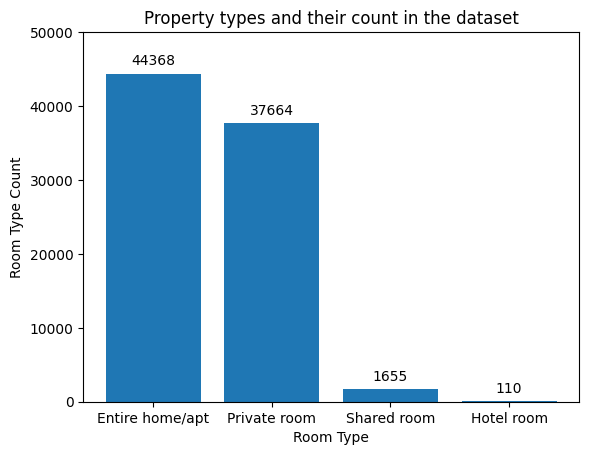

In [18]:
room_type_bar = plt.bar(property_types.index, property_types.loc[:, "count"]);
plt.bar_label(room_type_bar, labels = property_types.loc[:, "count"], padding = 4);
plt.ylim([0, 50000]);
plt.xlabel("Room Type");
plt.ylabel("Room Type Count");
plt.title("Property types and their count in the dataset");

The Airbnb open dataset reveals four distinct property or room types. These categories comprises:


*   Entire home/apt
*   Private room
*   Shared room
*   Hotel room

Notably, the barchart illustrates that entire home/apt dominates the dataset with 44368 occurences, followed by private room with 37664 occurences. Shared room and hotel room trail behind with 1655 and 110 occurences respectively.





In [20]:
hood_group = df['neighbourhood group'].value_counts().to_frame()
hood_group

,count
neighbourhood group,
Brooklyn,34779
Manhattan,34736
Queens,11184
Bronx,2276
Staten Island,821
brookln,1


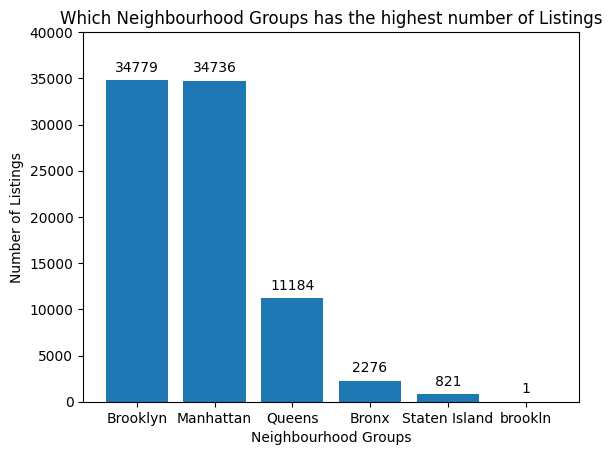

In [22]:
#Which neighbourhood group has the highest number of listings?
hood_group_bar = plt.bar(hood_group.index, hood_group.loc[:, "count"]);
plt.bar_label(hood_group_bar, labels = hood_group.loc[:, "count"], padding = 4);
plt.ylim([0, 40000]);
plt.xlabel("Neighbourhood Groups");
plt.ylabel("Number of Listings");
plt.title("Which Neighbourhood Groups has the highest number of Listings");

The dataset contains five different neighbourhood groups, namely Brooklyn, Manhattan, Queens, Bronx and Staten Island. According to the barchart. Brooklyn has the highest number of listings with 34779, followed closely by Manhattan with 34736.

###Which Neighbourhood group have the highest average prices for AirBnb Listings?

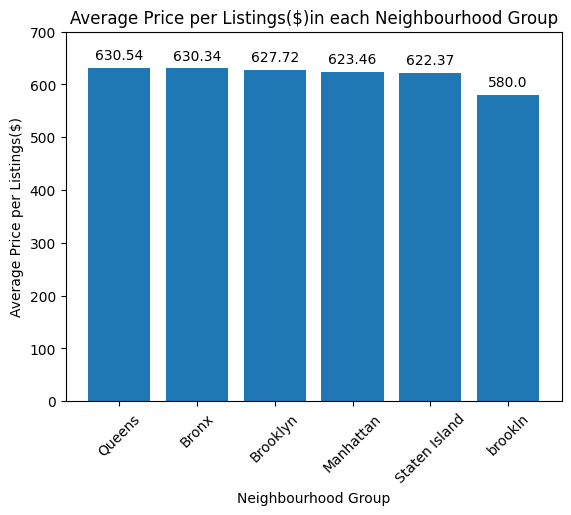

In [24]:
#Which neighbourhood group have the highest average prices for Airbnb Listings?

avg_price = df.groupby('neighbourhood group')['price_$'].mean().sort_values(ascending = False).to_frame()
avg_price_bar = plt.bar(avg_price.index, avg_price.loc[:, "price_$"]);
plt.bar_label(avg_price_bar, labels = round(avg_price.loc[:, "price_$"], 2), label_type='edge', padding = 4);
plt.ylim([0, 700]);
plt.xlabel("Neighbourhood Group");
plt.ylabel("Average Price per Listings($)");
plt.xticks(rotation = 45);
plt.title("Average Price per Listings($)in each Neighbourhood Group");

Among the five identified neighbourhood groups in the datset, Queens baots the highest avg listing price at 630.54 USD , closely trailed by the Bronx with an avg listing price of 630.34 USD, Conversely, Brookln records the lowest avg listing price at 580.0 USD.

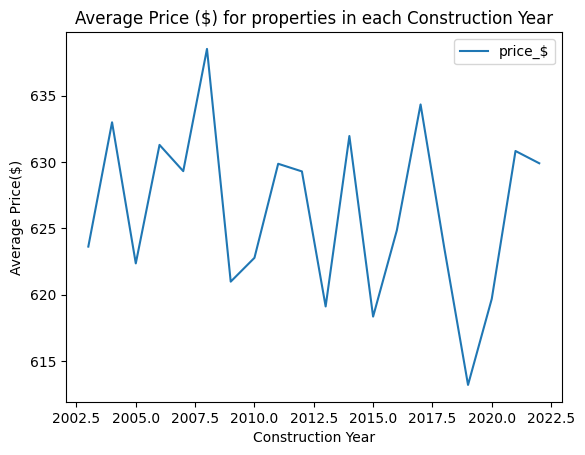

In [25]:
#Is there a relationship between the construction year of property and price?

df.groupby(df["Construction year"])["price_$"].mean().to_frame().plot();
plt.xlabel("Construction Year");
plt.ylabel("Average Price($)");
plt.title("Average Price ($) for properties in each Construction Year");

The line plot depicts the construction year of properties vs the avg price per property reveals a noticeable downward trend in prices as the construction years progress. The pattern demonstrates decreasing low and highs, suggesting an overall decline in property prices as time progresses.

### Who are the top 10 hosts by calculated host listing count?


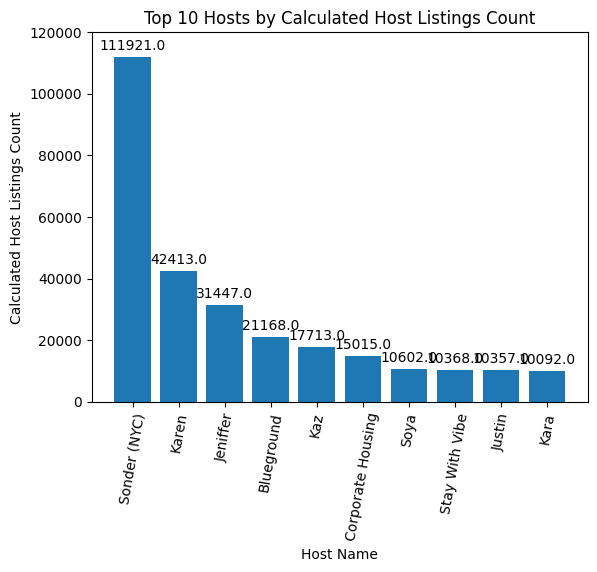

In [28]:
#Who are the top 10 hosts by calculated host listing count?

hosts = df.groupby("host name")["calculated host listings count"].sum().sort_values(ascending = False).to_frame().head(10)
hosts_bar = plt.bar(hosts.index, hosts.loc[:, "calculated host listings count"]);
plt.bar_label(hosts_bar, labels = hosts.loc[:, "calculated host listings count"],label_type = "edge",  padding = 3);
plt.xlabel("Host Name");
plt.ylabel("Calculated Host Listings Count");
plt.xticks(rotation = 80);
plt.ylim([0, 120000]);
plt.ylabel("Calculated Host Listings Count");
plt.title("Top 10 Hosts by Calculated Host Listings Count");


The barchart above illustrates the top 10 hosts by calculated host listing count, with Sonder(NYC) notably leading with 111,921 listings.Subsequently, the other hosts follow in descending order.

### Are hosts with verified identities more likely to recieve positive reviews?

In [30]:
#Are hosts with verified identities more likely to recieve positive reviews?
review = df.groupby("host_identity_verified")["review rate number"].mean().sort_values(ascending= False).to_frame()
review

,review rate number
host_identity_verified,
verified,3.283897
unconfirmed,3.273786


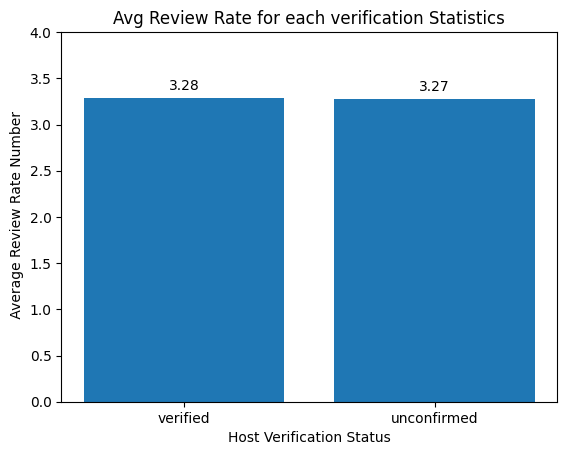

In [31]:
review_bar = plt.bar(review.index, review.loc[:, "review rate number"]);
plt.bar_label(review_bar, labels = round(review.loc[:, "review rate number"], 2), padding = 4);
plt.ylim([0, 4]);
plt.xlabel("Host Verification Status");
plt.ylabel(" Average Review Rate Number");
plt.title("Avg Review Rate for each verification Statistics");


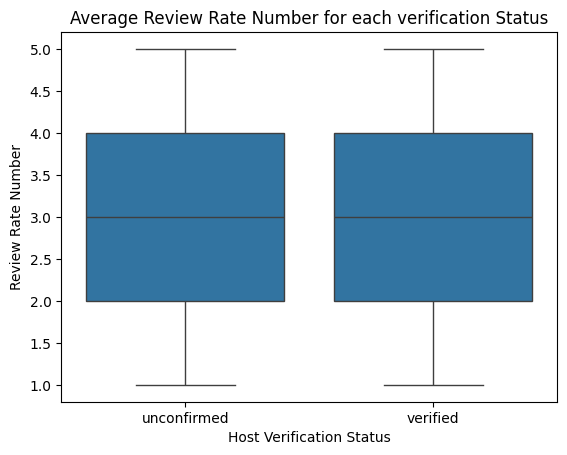

In [32]:
base_color = sns.color_palette()[0]
sns.boxplot(data = df, x = "host_identity_verified", y = "review rate number", color = base_color);
plt.xlabel("Host Verification Status");
plt.ylabel("Review Rate Number");
plt.title("Average Review Rate Number for each verification Status");

The avg review rates for verified and unconfirmed hosts are 3.27 and 3.28, repectively, indicating a marginal difference in their review rates, the unconfirmed hosts having a slighlty higher rate. This suggests that verified hosts are not necessarily more likely to recieve positive reviews compared to unconfirmed hosts

### Is there a correlation between the price of a listing and its service fee?

In [33]:
#Is there a correlation between the price of a listing and its service fee?
df['price_$'].corr(df['service_fee_$'])


np.float64(0.9999909085489923)

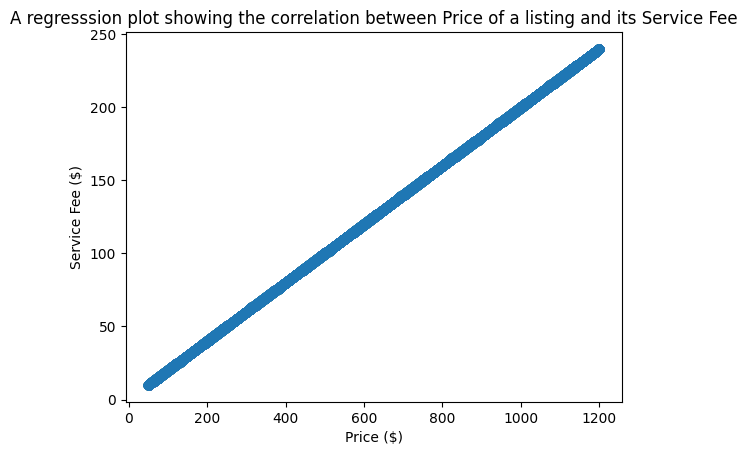

In [34]:
sns.regplot(df, x = 'price_$', y = 'service_fee_$');
plt.xlabel("Price ($)");
plt.ylabel("Service Fee ($)");
plt.title("A regresssion plot showing the correlation between Price of a listing and its Service Fee");

The Pearson correlation coeeficient between the price and service fee is 0.99, indicating a highly robust positive correlation between these variables. On th regression plot, each point forms a rising diagonal line towards the right, signifying that as the price of a property increases, so does its service fee.

### What is the avg review rate number (e.g.,stars) for listings , and does it vary based on the neighbourhood group and room type?

In [35]:
#What is the avg review rate number (e.g.,stars) for listings , and does it vary based on the neighbourhood group and room type?

ARRN = df.groupby(["neighbourhood group", "room type"])["review rate number"].mean().to_frame()
ARRN

review rate number
neighbourhood group room type                          
Bronx               Entire home/apt            3.379863
                    Private room               3.312548
                    Shared room                3.356322
Brooklyn            Entire home/apt            3.243013
                    Hotel room                 3.833333
                    Private room               3.274729
                    Shared room                3.322368
Manhattan           Entire home/apt            3.269024
                    Hotel room                 3.500000
                    Private room               3.285628
                    Shared room                3.252976
Queens              Entire home/apt            3.347437
                    Hotel room                 3.750000
                    Private room               3.311761
                    Shared room                3.327402
Staten Island       Entire home/apt            3.334129
                    Private room               3.493671
                    Shared room                3.714286
brookln             Private room               4.000000

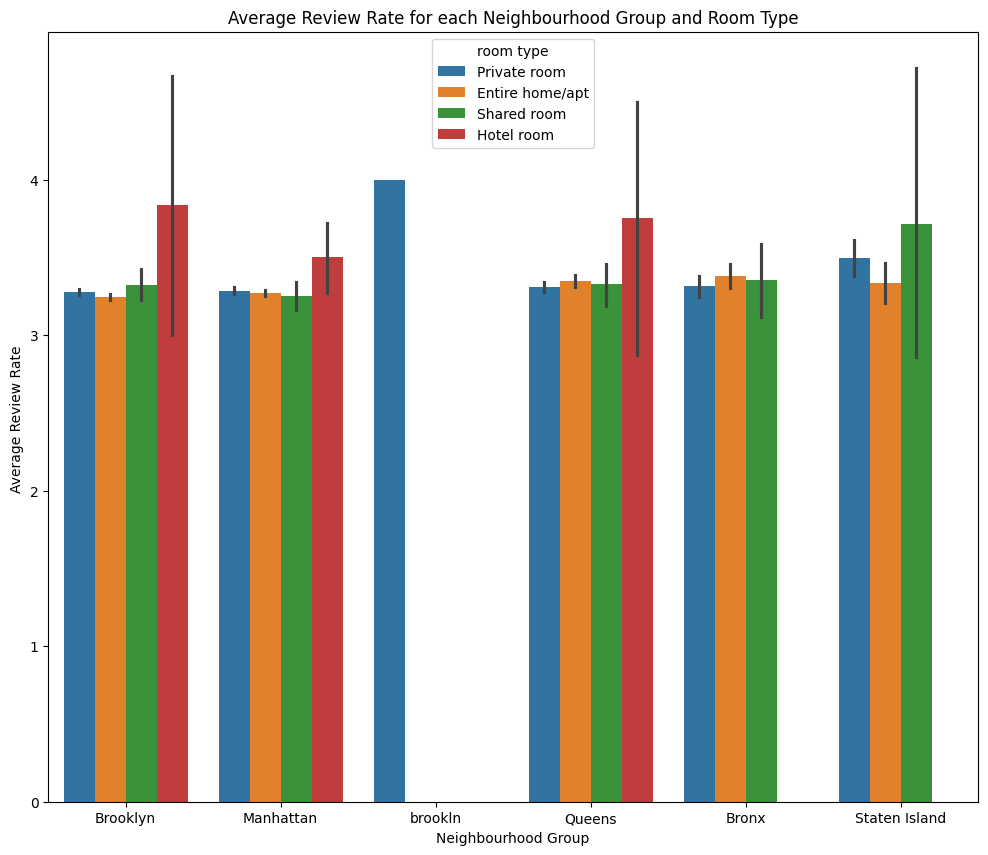

In [36]:
plt.figure(figsize = [12,10]);
sns.barplot(data = df, x = "neighbourhood group", y = "review rate number", hue = "room type");
plt.xlabel("Neighbourhood Group");
plt.ylabel("Average Review Rate ");
plt.title("Average Review Rate for each Neighbourhood Group and Room Type");

Hotel rooms exhibit has higher review rate compared to all other property types within the three neighbourhood groups where they are located:Brooklyn, Manhattan and Queens.

### Are hosts with a higher calculated host listings count more likely to maintain higher availabilty throughout the year?

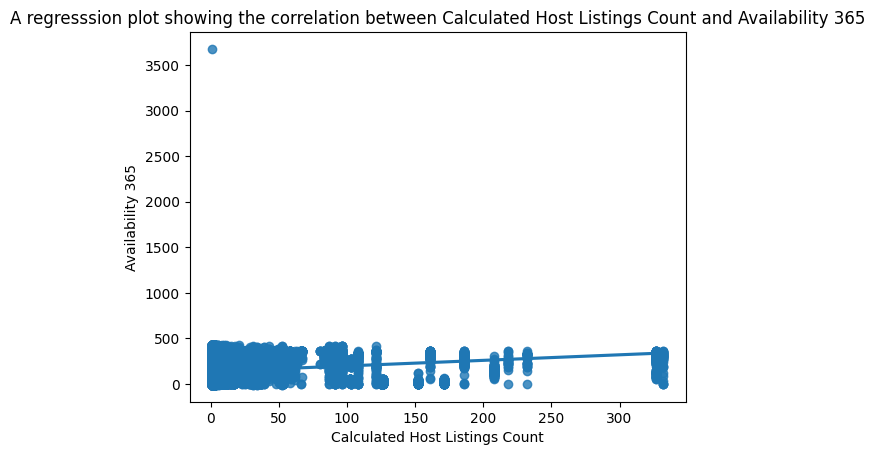

In [37]:
#Are hosts with a higher calculated host listings count more likely to maintain higher availabilty throughout the year?
sns.regplot(df, x = "calculated host listings count", y = "availability 365");
plt.xlabel("Calculated Host Listings Count");
plt.ylabel("Availability 365");
plt.title("A regresssion plot showing the correlation between Calculated Host Listings Count and Availability 365");

In [39]:
df["calculated host listings count"].corr(df["availability 365"])

np.float64(0.1347092579208049)

# Conclusion

In conclusion, this project has provided a comprehensive analysis of the New York City Airbnb dataset, shedding light on various aspects of the short-term lodging market. Through data wrangling, exploratory data analysis (EDA), and interpretation of summary statistics, we've uncovered valuable insights into listing distribution, pricing dynamics, host, and review analysis.

Key findings include the dominance in counts of Entire home/apt listings, the variability in listing counts across neighborhood groups, and the downward trend between property construction year and price. Additionally, the analysis highlighted the significance of verified host status on review rates, as well as the strong correlation between listing price and service fee.

Furthermore, conducting sentiment analysis on guest reviews to understand factors driving customer satisfaction and preferences could inform targeted marketing strategies and product improvements for Airbnb. Lastly, expanding the analysis to include predictive modeling techniques, such as regression or machine learning algorithms, could enable forecasting of listing demand, pricing trends, and customer behavior, facilitating strategic decision-making for stakeholders in the short-term lodging industry.